In [1]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas
import seaborn
import numpy
from scipy.interpolate import interp1d


%matplotlib inline
plt.rcParams['savefig.format'] = 'png'
plt.rcParams["font.family"] = 'serif'
DATASETS = ["Erdös-Rényi","AQSOL", "PCQM4Mv2", "OGBN-Arxiv", "CoraFull"]

def table(BASE_DATASET):
    dataset_name = None
    if BASE_DATASET == "Erdös-Rényi":
        dataset_name = "er"
    elif BASE_DATASET == "AQSOL":
        dataset_name = "aqsol"
    elif BASE_DATASET == "PCQM4Mv2":
        dataset_name = "pcqm4mv2"
    elif BASE_DATASET == "OGBN-Arxiv":
        dataset_name = "ogbn-arxiv"
    elif BASE_DATASET == "CoraFull":
        dataset_name = "corafull"

    df = pandas.concat([pandas.read_csv(f"../results/run-{i}/{dataset_name}.csv").sort_values("Name").fillna("Laplacian") for i in range(8)])
    def path_to_noise(path: str) -> float:
        if "0.04" in path:
            return 0.04
        elif "0.06" in path:
            return 0.06
        elif "0.08" in path:
            return 0.08
        elif "0.12" in path:
            return 0.12
        elif "0.15" in path:
            return 0.15
        elif "0.18" in path:
            return 0.18
        elif "0.24" in path:
            return 0.24
        elif "0.3" in path:
            return 0.30
        
    median = df.groupby(["model","dataset"])["lap/val"].median()
    result_df = pandas.DataFrame(index=["GCN", "GIN", "GatedGCN", "GAT", "GATv2"], columns=[0.04, 0.06, 0.08, 0.12, 0.15, 0.18, 0.24, 0.30])

    for key in median.keys():
        if key[0] != "Laplacian":
            result_df.loc[key[0], path_to_noise(key[1])] = round(median[key]*100,1)

    return result_df


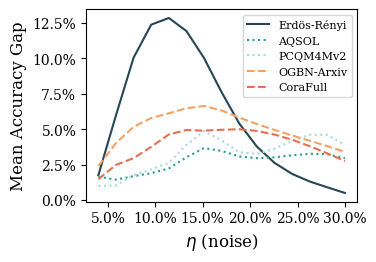

In [19]:
COLORS = ["#264653", "#2a9d8f", "#a8dadc", "#f4a261", "#e76f51"]
LINESTYLE = ["-", ":", ":", "--", "--"]
MODELS = ["GCN", "GIN", "GatedGCN", "GAT", "GATv2"]
NOISES = [0.04, 0.06, 0.08, 0.12, 0.15, 0.18, 0.24, 0.30]
fig, ax = plt.subplots(figsize=(3.5,2.5))
def build_figure(BASE_DATASET, color, ls):
    lines = []
    for i in range(len(MODELS)):
        for j in range(len(MODELS)):
            if j > i and i==0:
                m1 = MODELS[i]
                m2 = MODELS[j]
                df = table(BASE_DATASET)
                line = numpy.zeros((len(NOISES,)))
                for k,noise in enumerate(NOISES):
                    line[k] = abs(df.loc[m1, noise] - df.loc[m2, noise])
                lines.append(line)
    #plt.plot(NOISES,line/max_difference, color=color, alpha=0.15)
    xnew = numpy.linspace(0.04, 0.3, num=15, endpoint=True)
    f_cubic = interp1d(NOISES, numpy.mean(numpy.array(lines), axis=0), kind='cubic')
    ax.plot(xnew, f_cubic(xnew)/100, color=color, linewidth=1.5, label=BASE_DATASET, ls=ls)

[build_figure(BASE_DATASET, COLOR, LS) for BASE_DATASET, COLOR, LS in zip(DATASETS, COLORS, LINESTYLE)]
plt.legend(fontsize=8)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.xticks(fontsize=10)
ax.set_xlabel(r"$\eta$ (noise)", fontsize=12)
ax.set_ylabel("Mean Accuracy Gap", fontsize=12)

plt.savefig("optimal-noise.pdf", bbox_inches='tight', pad_inches=0.2)